In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.io as pio

pio.renderers.default = "notebook"
sns.set(style="whitegrid")

os.makedirs("visualizations", exist_ok=True)

In [2]:
df = pd.read_csv("sales_data.csv")

df["Date"] = pd.to_datetime(df["Date"])

df.head()

,Date,Product,Quantity,Price,Customer_ID,Region,Total_Sales
0,2024-01-01,Phone,7,37300,CUST001,East,261100
1,2024-01-02,Headphones,4,15406,CUST002,North,61624
2,2024-01-03,Phone,2,21746,CUST003,West,43492
3,2024-01-04,Headphones,1,30895,CUST004,East,30895
4,2024-01-05,Laptop,8,39835,CUST005,North,318680


In [3]:
print(df.info())

print()

print(df.describe())

print()

print(df.isnull().sum())

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Date         100 non-null    datetime64[us]
 1   Product      100 non-null    str           
 2   Quantity     100 non-null    int64         
 3   Price        100 non-null    int64         
 4   Customer_ID  100 non-null    str           
 5   Region       100 non-null    str           
 6   Total_Sales  100 non-null    int64         
dtypes: datetime64[us](1), int64(3), str(3)
memory usage: 5.6 KB
None

                      Date    Quantity         Price    Total_Sales
count                  100  100.000000    100.000000     100.000000
mean   2024-02-19 12:00:00    4.780000  25808.510000  123650.480000
min    2024-01-01 00:00:00    1.000000   1308.000000    6540.000000
25%    2024-01-25 18:00:00    2.750000  14965.250000   39517.500000
50%    2024-02-19 12:00:00    5.000000  24192.000000   9

In [4]:
df.drop_duplicates(inplace=True)

df.fillna(0, inplace=True)

df.head()

,Date,Product,Quantity,Price,Customer_ID,Region,Total_Sales
0,2024-01-01,Phone,7,37300,CUST001,East,261100
1,2024-01-02,Headphones,4,15406,CUST002,North,61624
2,2024-01-03,Phone,2,21746,CUST003,West,43492
3,2024-01-04,Headphones,1,30895,CUST004,East,30895
4,2024-01-05,Laptop,8,39835,CUST005,North,318680


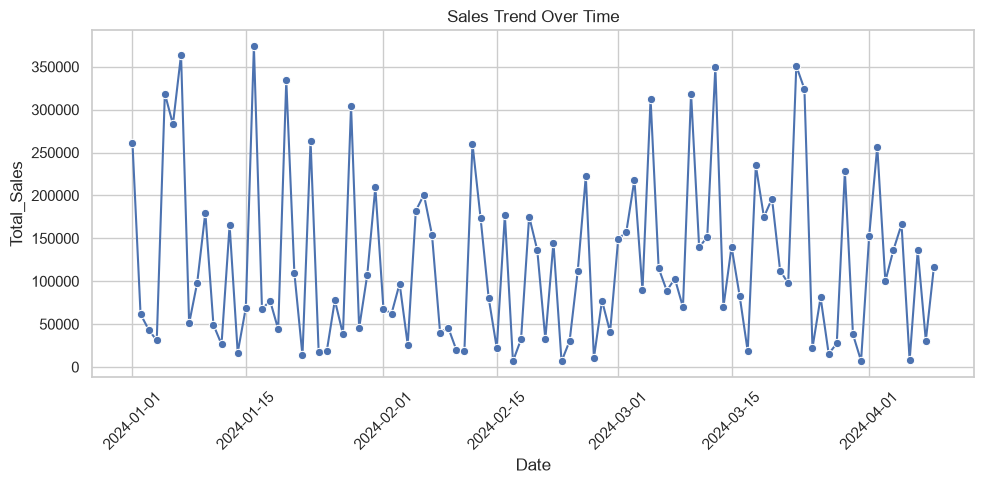

In [5]:
plt.figure(figsize=(10,5))

sns.lineplot(
    data=df,
    x="Date",
    y="Total_Sales",
    marker="o"
)

plt.title("Sales Trend Over Time")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig("visualizations/line_chart.png")

plt.show()

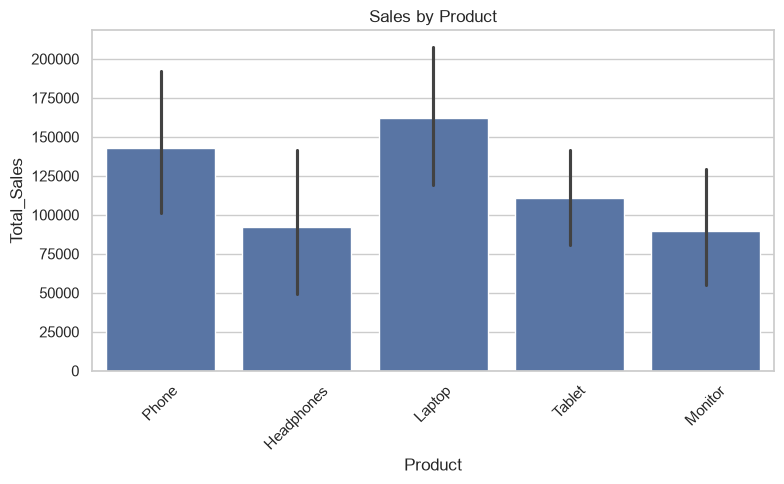

In [6]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x="Product",
    y="Total_Sales"
)

plt.title("Sales by Product")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig("visualizations/bar_chart.png")

plt.show()

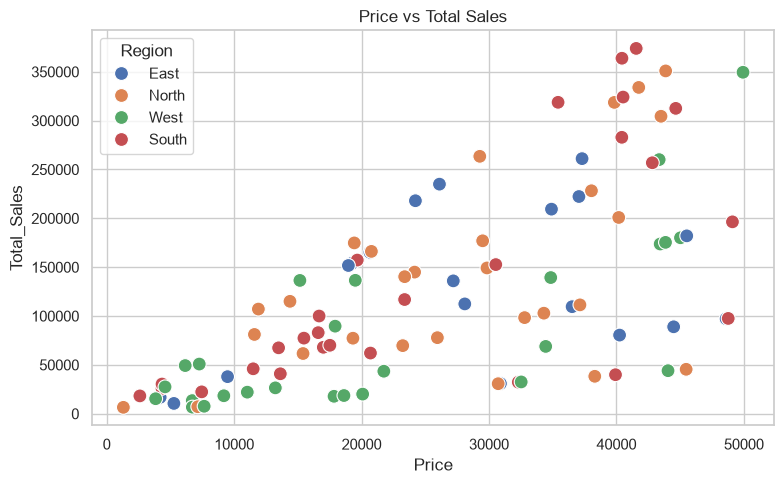

In [7]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="Price",
    y="Total_Sales",
    hue="Region",
    s=100
)

plt.title("Price vs Total Sales")

plt.tight_layout()

plt.savefig("visualizations/scatter_plot.png")

plt.show()

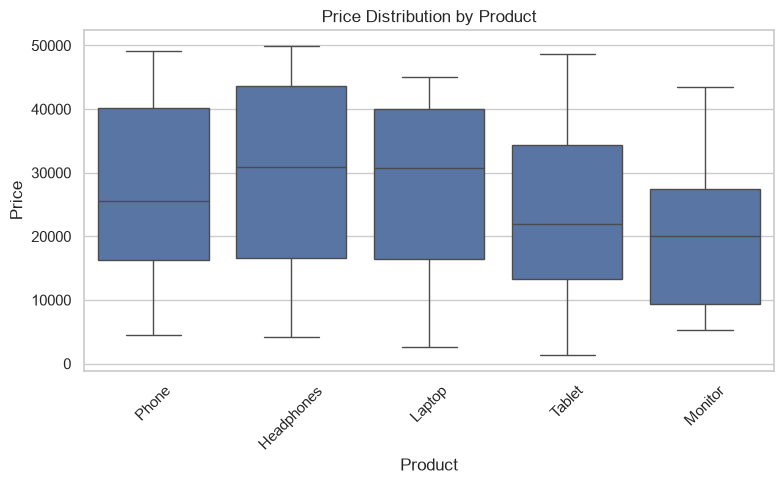

In [8]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Product",
    y="Price"
)

plt.title("Price Distribution by Product")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig("visualizations/box_plot.png")

plt.show()

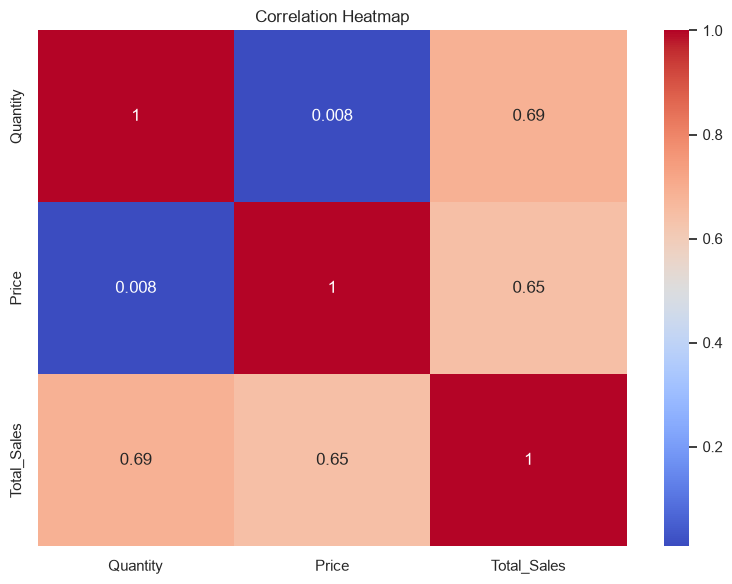

In [9]:
plt.figure(figsize=(8,6))

corr = df[["Quantity","Price","Total_Sales"]].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.tight_layout()

plt.savefig("visualizations/heatmap.png")

plt.show()

In [11]:
fig = px.bar(
    df,
    x="Product",
    y="Total_Sales",
    color="Region",
    title="Interactive Sales by Product"
)

fig.show()

ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

In [12]:
fig = px.line(
    df,
    x="Date",
    y="Total_Sales",
    markers=True,
    title="Interactive Sales Trend"
)

fig.show()

ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

In [ ]:
product_sales = df.groupby("Product", as_index=False)["Total_Sales"].sum()

fig = px.pie(
    product_sales,
    names="Product",
    values="Total_Sales",
    title="Sales Share by Product"
)

fig.show()

In [ ]:
print("="*60)

print("BUSINESS INSIGHTS")

print("="*60)

print("Total Revenue :", df["Total_Sales"].sum())

print("Average Revenue :", round(df["Total_Sales"].mean(),2))

print("Highest Revenue :", df["Total_Sales"].max())

print("Lowest Revenue :", df["Total_Sales"].min())

print()

print("Revenue by Product")

print(df.groupby("Product")["Total_Sales"].sum())

print()

print("Revenue by Region")

print(df.groupby("Region")["Total_Sales"].sum())

print()

print("Average Price :", round(df["Price"].mean(),2))

print("Average Quantity :", round(df["Quantity"].mean(),2))